In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv('../data/22_열처리.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

## 실습 2. 단일 센서 이동평균 추적
창 크기 10 이동평균을 원본에 겹쳐 추세 읽기

목표
- 창 크기 10 이동평균을 구해 원본 위에 겹쳐 추세를 읽기

단계
- 센서에 창 크기 10 이동평균을 새 열로 담기
- 원본을 옅게, 이동평균을 진하게 겹쳐 그리기
- 이동평균선이 추세를 드러냄을 확인

예상 결과
- 들쭉날쭉한 원본 위로 매끈한 이동평균 추세선

(1250, 7)
[nan, nan, nan, nan, nan, nan, nan, nan, nan, 0.0, 0.0]


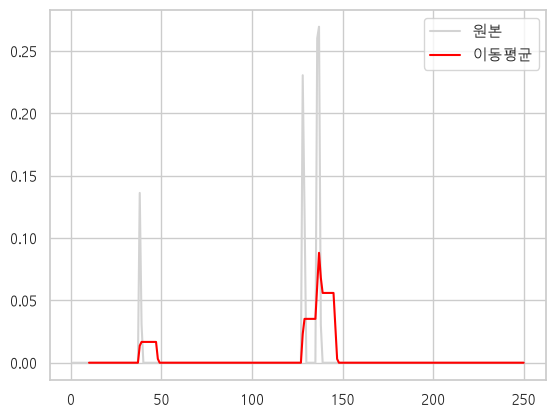

In [ ]:
df = pd.read_csv("23_전기Panel.csv")
print(df.shape) # (1250, 7)

eng2 = df[df['설비번호'] == 2].copy().sort_values('시퀀스').reset_index(drop=True)

eng2['ma10'] = eng2['컨베이어전류'].rolling(window=10).mean()
print(eng2['ma10'].head(11).round(4).tolist())    # 앞 9개 nan

# 원본 옅게
plt.plot(eng2['시퀀스'], eng2['컨베이어전류'], color='lightgray', label='원본')
# 이동평균 진하게
plt.plot(eng2['시퀀스'], eng2['ma10'], color='red', label='이동평균')
plt.legend()
plt.show()